## Camera-Length DAC Curves

This section adds the raw DAC table keyed by camera length in mm and visualizes the lens trends in the same multi-panel style used at the start of the DAC inversion notebook.

The plots emphasize:
- the intermediate-lens trends (IL1, IL2, IL3)
- the mostly fixed projector/objective settings
- the zoom-pair sum $\mathrm{IL2} + \mathrm{IL3}$
- total current-like sums across the column

## Input Data and Reference Curves

Use the next code cell to define raw DAC tables, parse them, and inspect reference trends before fitting.

Rc at 200 kV = 5.301506e-04 rad/AT
Imaging M_IL:  10.0 to 200.0  (14 points)
Camera  M_IL: -8.696 to -0.348 (15 points)

Camera-length table:
  CL(mm)     M_IL     IL1     IL2     IL3     PL1     OLc  IL2+IL3
------------------------------------------------------------------
      80   -0.348   20600   44737   37532   64000   45818    82269
     100   -0.435   21093   44969   37175   64000   45818    82144
     120   -0.522   21025   45238   36833   64000   45818    82071
     150   -0.652   21310   45485   36324   64000   45818    81809
     200   -0.870   21310   46044   35503   64000   45818    81547
     250   -1.087   21379   46751   34710   64000   45818    81461
     300   -1.304   21417   47247   33951   64000   45818    81198
     400   -1.739   21427   48739   32605   64000   45818    81344
     500   -2.174   21387   50461   31219   64000   45818    81680
     600   -2.609   21377   51504   29952   64000   45818    81456
     800   -3.478   21259   53888   27616   64000   45

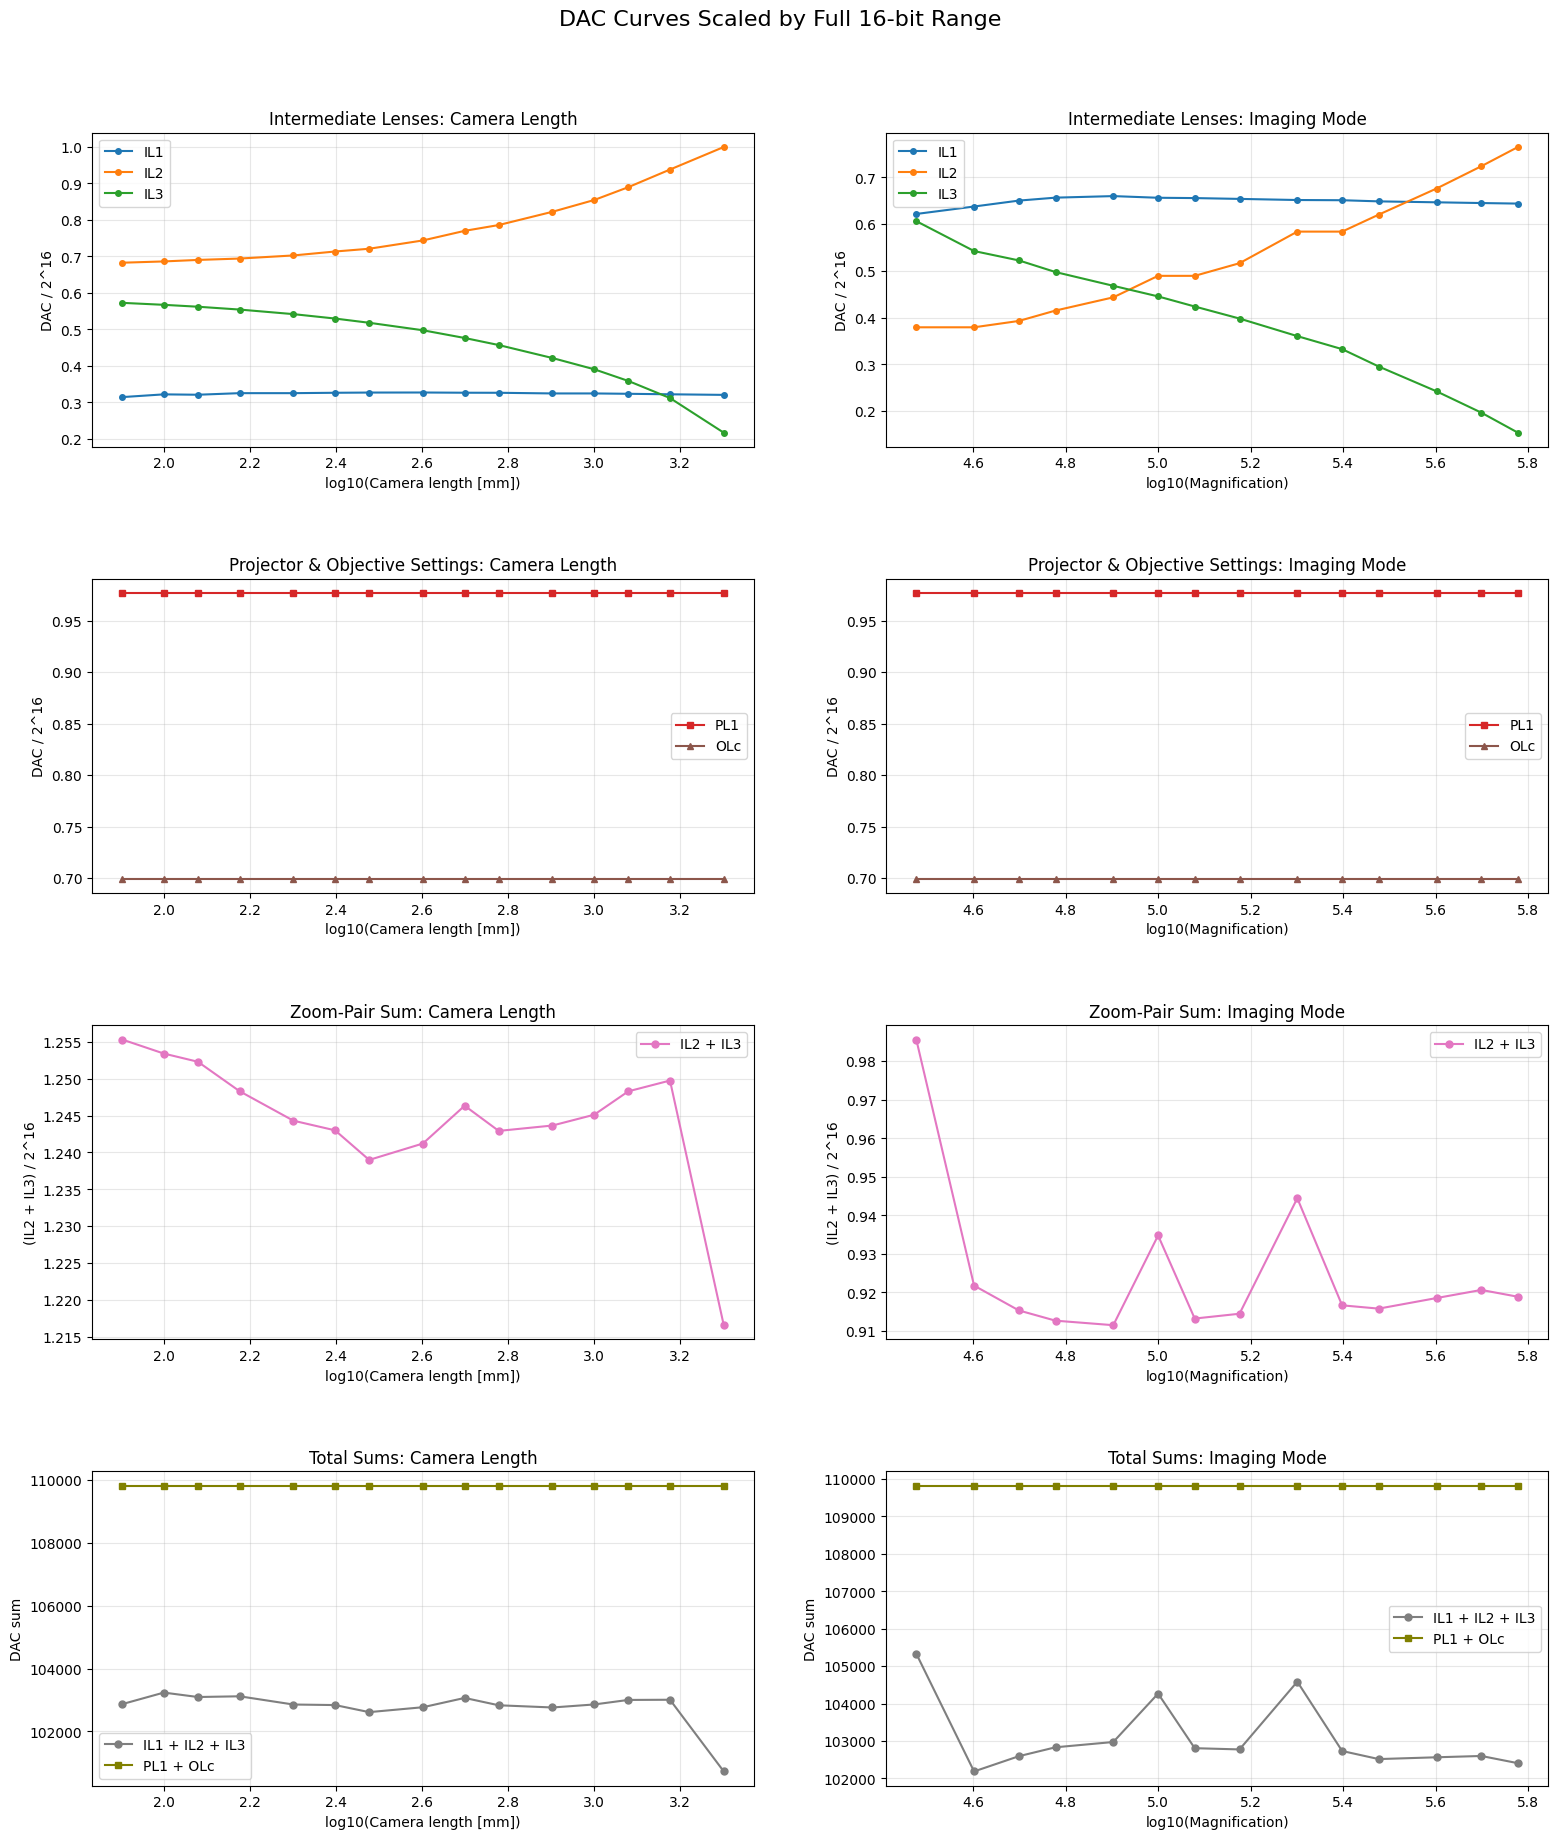

In [3]:
import numpy as np
import matplotlib.pyplot as plt

CAMERA_LENGTH_RAW_DAC_HEX = {
    "80": {
        "OLc": "0xb2fa",
        "OLf": "0x981a",
        "OLSuperFineValue": "0x800",
        "OM2": "0x0",
        "IL1": "0x5078",
        "IL2": "0xaec1",
        "IL3": "0x929c",
        "PL1": "0xfa00"
    },
    "100": {
        "OLc": "0xb2fa",
        "OLf": "0x981a",
        "OLSuperFineValue": "0x800",
        "OM2": "0x0",
        "IL1": "0x5265",
        "IL2": "0xafa9",
        "IL3": "0x9137",
        "PL1": "0xfa00"
    },
    "120": {
        "OM2": "0x0",
        "IL1": "0x5221",
        "IL2": "0xb0b6",
        "IL3": "0x8fe1",
        "PL1": "0xfa00",
        "OLc": "0xb2fa",
        "OLf": "0x981a",
        "OLSuperFineValue": "0x800"
    },
    "150": {
        "OM2": "0x0",
        "IL1": "0x533e",
        "IL2": "0xb1ad",
        "IL3": "0x8de4",
        "PL1": "0xfa00",
        "OLc": "0xb2fa",
        "OLf": "0x981a",
        "OLSuperFineValue": "0x800"
    },
    "200": {
        "IL2": "0xb3dc",
        "IL3": "0x8aaf",
        "PL1": "0xfa00",
        "OLc": "0xb2fa",
        "OLf": "0x981a",
        "OLSuperFineValue": "0x800",
        "OM2": "0x0",
        "IL1": "0x533e"
    },
    "250": {
        "OLSuperFineValue": "0x800",
        "OM2": "0x0",
        "IL1": "0x5383",
        "IL2": "0xb69f",
        "IL3": "0x8796",
        "PL1": "0xfa00",
        "OLc": "0xb2fa",
        "OLf": "0x981a"
    },
    "300": {
        "OLf": "0x981a",
        "OLSuperFineValue": "0x800",
        "OM2": "0x0",
        "IL1": "0x53a9",
        "IL2": "0xb88f",
        "IL3": "0x849f",
        "PL1": "0xfa00",
        "OLc": "0xb2fa"
    },
    "400": {
        "IL1": "0x53b3",
        "IL2": "0xbe63",
        "IL3": "0x7f5d",
        "PL1": "0xfa00",
        "OLc": "0xb2fa",
        "OLf": "0x981a",
        "OLSuperFineValue": "0x800",
        "OM2": "0x0"
    },
    "500": {
        "OM2": "0x0",
        "IL1": "0x538b",
        "IL2": "0xc51d",
        "IL3": "0x79f3",
        "PL1": "0xfa00",
        "OLc": "0xb2fa",
        "OLf": "0x981a",
        "OLSuperFineValue": "0x800"
    },
    "600": {
        "OM2": "0x0",
        "IL1": "0x5381",
        "IL2": "0xc930",
        "IL3": "0x7500",
        "PL1": "0xfa00",
        "OLc": "0xb2fa",
        "OLf": "0x981a",
        "OLSuperFineValue": "0x800"
    },
    "800": {
        "IL1": "0x530b",
        "IL2": "0xd280",
        "IL3": "0x6be0",
        "PL1": "0xfa00",
        "OLc": "0xb2fa",
        "OLf": "0x981a",
        "OLSuperFineValue": "0x800",
        "OM2": "0x0"
    },
    "1000": {
        "IL2": "0xdac0",
        "IL3": "0x6400",
        "PL1": "0xfa00",
        "OLc": "0xb2fa",
        "OLf": "0x981a",
        "OLSuperFineValue": "0x800",
        "OM2": "0x0",
        "IL1": "0x530b"
    },
    "1200": {
        "OM2": "0x0",
        "IL1": "0x52cb",
        "IL2": "0xe3c0",
        "IL3": "0x5bd0",
        "PL1": "0xfa00",
        "OLc": "0xb2fa",
        "OLf": "0x981a",
        "OLSuperFineValue": "0x800"
    },
    "1500": {
        "IL2": "0xf020",
        "IL3": "0x4fd0",
        "PL1": "0xfa00",
        "OLc": "0xb2fa",
        "OLf": "0x981a",
        "OLSuperFineValue": "0x800",
        "OM2": "0x0",
        "IL1": "0x5271"
    },
    "2000": {
        "OM2": "0x0",
        "IL1": "0x5208",
        "IL2": "0xfff0",
        "IL3": "0x3780",
        "PL1": "0xfa00",
        "OLc": "0xb2fa",
        "OLf": "0x981a",
        "OLSuperFineValue": "0x800"
    }
}

IMAGING_MODE_RAW_DAC_HEX = {
    "30000": {"IL1": "0x9f22", "IL2": "0x611e", "IL3": "0x9b35", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "40000": {"IL1": "0xa336", "IL2": "0x611e", "IL3": "0x8ad8", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "50000": {"IL1": "0xa674", "IL2": "0x6498", "IL3": "0x85b7", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "60000": {"IL1": "0xa810", "IL2": "0x6a48", "IL3": "0x7f59", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "80000": {"IL1": "0xa8ea", "IL2": "0x7182", "IL3": "0x77d2", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "100000": {"IL1": "0xa800", "IL2": "0x7d46", "IL3": "0x7205", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "120000": {"IL1": "0xa7d4", "IL2": "0x7d46", "IL3": "0x6c7f", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "150000": {"IL1": "0xa761", "IL2": "0x8431", "IL3": "0x65e6", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "200000": {"IL1": "0xa6c5", "IL2": "0x957b", "IL3": "0x5c4a", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "250000": {"IL1": "0xa6a8", "IL2": "0x957b", "IL3": "0x552b", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "300000": {"IL1": "0xa608", "IL2": "0x9ec6", "IL3": "0x4ba8", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "400000": {"IL1": "0xa584", "IL2": "0xad0c", "IL3": "0x3e16", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "500000": {"IL1": "0xa51d", "IL2": "0xb944", "IL3": "0x3268", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "600000": {"IL1": "0xa4d0", "IL2": "0xc3c7", "IL3": "0x2771", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
}

# ============================================================
# Parse raw hex tables
# ============================================================
DAC_FULL_SCALE = float(2 ** 16)

def parse_hex_table(raw, primary_axis_name):
    primary_values = sorted(int(key) for key in raw)
    data = {
        primary_axis_name: np.array(primary_values, dtype=float),
        f"log_{primary_axis_name}": np.log10(primary_values),
    }
    example_entry = next(iter(raw.values()))
    for lens_name in example_entry:
        data[lens_name] = np.array(
            [int(raw[str(primary_value)][lens_name], 16) for primary_value in primary_values],
            dtype=float,
        )
    return data

def scale_to_full_dac(values):
    return np.asarray(values, dtype=float) / DAC_FULL_SCALE

camera_length_dac = parse_hex_table(CAMERA_LENGTH_RAW_DAC_HEX, "camera_length_mm")
imaging_mode_dac = parse_hex_table(IMAGING_MODE_RAW_DAC_HEX, "magnification")

# ============================================================
# Physical constants (given / assumed)
# ============================================================
F_OBJ_MM = 2.3         # objective focal length [mm]
M_OBJ = -30.0          # objective magnification
M_PROJ = -100.0        # projector magnification
I_MAX = 5.0            # DAC full-scale current [A]
N_TURNS = np.array([3000.0, 2000.0, 2000.0])  # IL1, IL2, IL3 turns

NI_MAX = N_TURNS * I_MAX  # max ampere-turns per lens

# Rotation constant Rc — fixed from accelerating voltage (200 kV)
# Rc = e·μ₀ / (2·mₑ·v), where v is the relativistic electron velocity
U_ACCEL = 200e3  # accelerating voltage [V]
_e = 1.602176634e-19   # elementary charge [C]
_me = 9.1093837015e-31 # electron rest mass [kg]
_c = 299792458.0        # speed of light [m/s]
_mu0 = 1.25663706212e-6 # vacuum permeability [H/m]
_gamma_rel = 1.0 + _e * U_ACCEL / (_me * _c**2)
_v_electron = _c * np.sqrt(1.0 - 1.0 / _gamma_rel**2)
RC = float(_e * _mu0 / (2.0 * _me * _v_electron))  # rad/AT
print(f"Rc at {U_ACCEL/1e3:.0f} kV = {RC:.6e} rad/AT")

# ============================================================
# Imaging-mode DAC references (normalised)
# ============================================================
mags_ref = np.array(sorted(int(k) for k in IMAGING_MODE_RAW_DAC_HEX), dtype=float)
dac1 = np.array([int(IMAGING_MODE_RAW_DAC_HEX[str(int(m))]["IL1"], 16) for m in mags_ref], dtype=float)
dac2 = np.array([int(IMAGING_MODE_RAW_DAC_HEX[str(int(m))]["IL2"], 16) for m in mags_ref], dtype=float)
dac3 = np.array([int(IMAGING_MODE_RAW_DAC_HEX[str(int(m))]["IL3"], 16) for m in mags_ref], dtype=float)
x1_ref, x2_ref, x3_ref = dac1 / 65535.0, dac2 / 65535.0, dac3 / 65535.0

# Target IL magnifications
#   Imaging: M_sys = M_obj × M_IL × M_proj  →  M_IL = M_sys / (M_obj × M_proj)
M_IL_IMAGING = mags_ref / (M_OBJ * M_PROJ)

# ============================================================
# Camera-length DAC references (normalised)
# ============================================================
cl_ref = np.asarray(camera_length_dac["camera_length_mm"], dtype=float)
x1_cl_ref = scale_to_full_dac(camera_length_dac["IL1"])
x2_cl_ref = scale_to_full_dac(camera_length_dac["IL2"])
x3_cl_ref = scale_to_full_dac(camera_length_dac["IL3"])

# Target IL magnifications
#   Camera length: CL = f_obj × M_IL × M_proj  →  M_IL = CL / (f_obj × M_proj)
M_IL_CAMERA = cl_ref / (F_OBJ_MM * M_PROJ)

print(f"Imaging M_IL:  {M_IL_IMAGING.min():.1f} to {M_IL_IMAGING.max():.1f}  ({len(M_IL_IMAGING)} points)")
print(f"Camera  M_IL: {M_IL_CAMERA.min():.3f} to {M_IL_CAMERA.max():.3f} ({len(M_IL_CAMERA)} points)")

# ============================================================
# Print DAC tables
# ============================================================
print("\nCamera-length table:")
print(
    f"{'CL(mm)':>8s} {'M_IL':>8s} {'IL1':>7s} {'IL2':>7s} {'IL3':>7s} {'PL1':>7s} {'OLc':>7s} {'IL2+IL3':>8s}"
)
print("-" * 66)
for index, camera_length in enumerate(camera_length_dac["camera_length_mm"]):
    il1 = camera_length_dac["IL1"][index]
    il2 = camera_length_dac["IL2"][index]
    il3 = camera_length_dac["IL3"][index]
    pl1 = camera_length_dac["PL1"][index]
    olc = camera_length_dac["OLc"][index]
    print(
        f"{camera_length:>8.0f} {M_IL_CAMERA[index]:>8.3f} {il1:>7.0f} {il2:>7.0f} {il3:>7.0f} {pl1:>7.0f} {olc:>7.0f} {il2 + il3:>8.0f}"
    )

print("\nImaging-mode table:")
print(
    f"{'Mag':>8s} {'M_IL':>8s} {'IL1':>7s} {'IL2':>7s} {'IL3':>7s} {'PL1':>7s} {'OLc':>7s} {'IL2+IL3':>8s}"
)
print("-" * 66)
for index, magnification in enumerate(imaging_mode_dac["magnification"]):
    il1 = imaging_mode_dac["IL1"][index]
    il2 = imaging_mode_dac["IL2"][index]
    il3 = imaging_mode_dac["IL3"][index]
    pl1 = imaging_mode_dac["PL1"][index]
    olc = imaging_mode_dac["OLc"][index]
    print(
        f"{magnification:>8.0f} {M_IL_IMAGING[index]:>8.1f} {il1:>7.0f} {il2:>7.0f} {il3:>7.0f} {pl1:>7.0f} {olc:>7.0f} {il2 + il3:>8.0f}"
    )

# ============================================================
# Visualise raw DAC curves
# ============================================================
fig, axes = plt.subplots(4, 2, figsize=(16, 19))

def plot_lens_panel(ax, data, x_key, title_suffix):
    for lens, color in zip(["IL1", "IL2", "IL3"], ["C0", "C1", "C2"]):
        ax.plot(
            data[x_key],
            scale_to_full_dac(data[lens]),
            "o-",
            label=lens,
            color=color,
            markersize=4,
        )
    ax.set_ylabel("DAC / 2^16")
    ax.set_title(f"Intermediate Lenses: {title_suffix}")
    ax.legend()
    ax.grid(True, alpha=0.3)

def plot_projector_panel(ax, data, x_key, title_suffix):
    for lens, style, color in [("PL1", "s-", "C3"), ("OLc", "^-", "C5")]:
        ax.plot(
            data[x_key],
            scale_to_full_dac(data[lens]),
            style,
            label=lens,
            color=color,
            markersize=4,
        )
    ax.set_ylabel("DAC / 2^16")
    ax.set_title(f"Projector & Objective Settings: {title_suffix}")
    ax.legend()
    ax.grid(True, alpha=0.3)

def plot_zoom_pair_panel(ax, data, x_key, title_suffix):
    il2_il3_sum = data["IL2"] + data["IL3"]
    ax.plot(
        data[x_key],
        scale_to_full_dac(il2_il3_sum),
        "o-",
        color="C6",
        markersize=5,
        label="IL2 + IL3",
    )
    ax.set_ylabel("(IL2 + IL3) / 2^16")
    ax.set_title(f"Zoom-Pair Sum: {title_suffix}")
    ax.grid(True, alpha=0.3)
    ax.legend()

def plot_total_panel(ax, data, x_key, title_suffix):
    il_total = data["IL1"] + data["IL2"] + data["IL3"]
    projector_objective_total = data["PL1"] + data["OLc"]
    ax.plot(
        data[x_key],
        il_total,
        "o-",
        color="C7",
        markersize=5,
        label="IL1 + IL2 + IL3",
    )
    ax.plot(
        data[x_key],
        projector_objective_total,
        "s-",
        color="olive",
        markersize=5,
        label="PL1 + OLc",
    )
    ax.set_ylabel("DAC sum")
    ax.set_title(f"Total Sums: {title_suffix}")
    ax.grid(True, alpha=0.3)
    ax.legend()

plot_lens_panel(axes[0, 0], camera_length_dac, "log_camera_length_mm", "Camera Length")
plot_lens_panel(axes[0, 1], imaging_mode_dac, "log_magnification", "Imaging Mode")

plot_projector_panel(axes[1, 0], camera_length_dac, "log_camera_length_mm", "Camera Length")
plot_projector_panel(axes[1, 1], imaging_mode_dac, "log_magnification", "Imaging Mode")

plot_zoom_pair_panel(axes[2, 0], camera_length_dac, "log_camera_length_mm", "Camera Length")
plot_zoom_pair_panel(axes[2, 1], imaging_mode_dac, "log_magnification", "Imaging Mode")

plot_total_panel(axes[3, 0], camera_length_dac, "log_camera_length_mm", "Camera Length")
plot_total_panel(axes[3, 1], imaging_mode_dac, "log_magnification", "Imaging Mode")

axes[0, 0].set_xlabel("log10(Camera length [mm])")
axes[0, 1].set_xlabel("log10(Magnification)")
axes[1, 0].set_xlabel("log10(Camera length [mm])")
axes[1, 1].set_xlabel("log10(Magnification)")
axes[2, 0].set_xlabel("log10(Camera length [mm])")
axes[2, 1].set_xlabel("log10(Magnification)")
axes[3, 0].set_xlabel("log10(Camera length [mm])")
axes[3, 1].set_xlabel("log10(Magnification)")

fig.suptitle(
    "DAC Curves Scaled by Full 16-bit Range",
    fontsize=16,
    y=0.985,
 )
fig.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.05,
    top=0.92,
    wspace=0.20,
    hspace=0.42,
 )
plt.show()

In [ ]:
f_obj = 2.3e-3 # objective focal length [m]
M_proj = 200.0  # projector magnification
M_obj = 80.0   # objective magnification


M_IL_camera_graph = cl_ref / (f_obj)
M_IL_image_graph = mags_ref / (M_obj)

print(M_IL_camera_graph, "\n", M_IL_image_graph)

[ 173.91304348  217.39130435  260.86956522  326.08695652  434.7826087
  543.47826087  652.17391304  869.56521739 1086.95652174 1304.34782609
 1739.13043478 2173.91304348 2608.69565217 3260.86956522 4347.82608696] 
 [ 1.875  2.5    3.125  3.75   5.     6.25   7.5    9.375 12.5   15.625
 18.75  25.    31.25  37.5  ]


Standalone outer calibration:
  status=3, nfev=16, cost=7835.0853, time=13.65 s
  alpha_use=[0.34308447 0.40044661 0.15269218]
  theta_img_use=3.0000, theta_cam_use=2.9999
Dimensionless solve setup:
  D_REF = 43.1875 mm
  USE_PREVIOUS_FIT_STATE = False
  eliminated variable: x1 from constant rotation
  optimized per target: (f2, f3) with data-normalised residuals
  initialization: data-independent multi-start
  weights: W_PHYS=0.35, W_TEL=0.010, W_DATA=2.50
  data residuals are non-dimensional: (x_model - x_ref) / sigma_x
  fast solve time  = 0.277 s
  full solve time  = 9.184 s
  speedup factor   = 33.19x


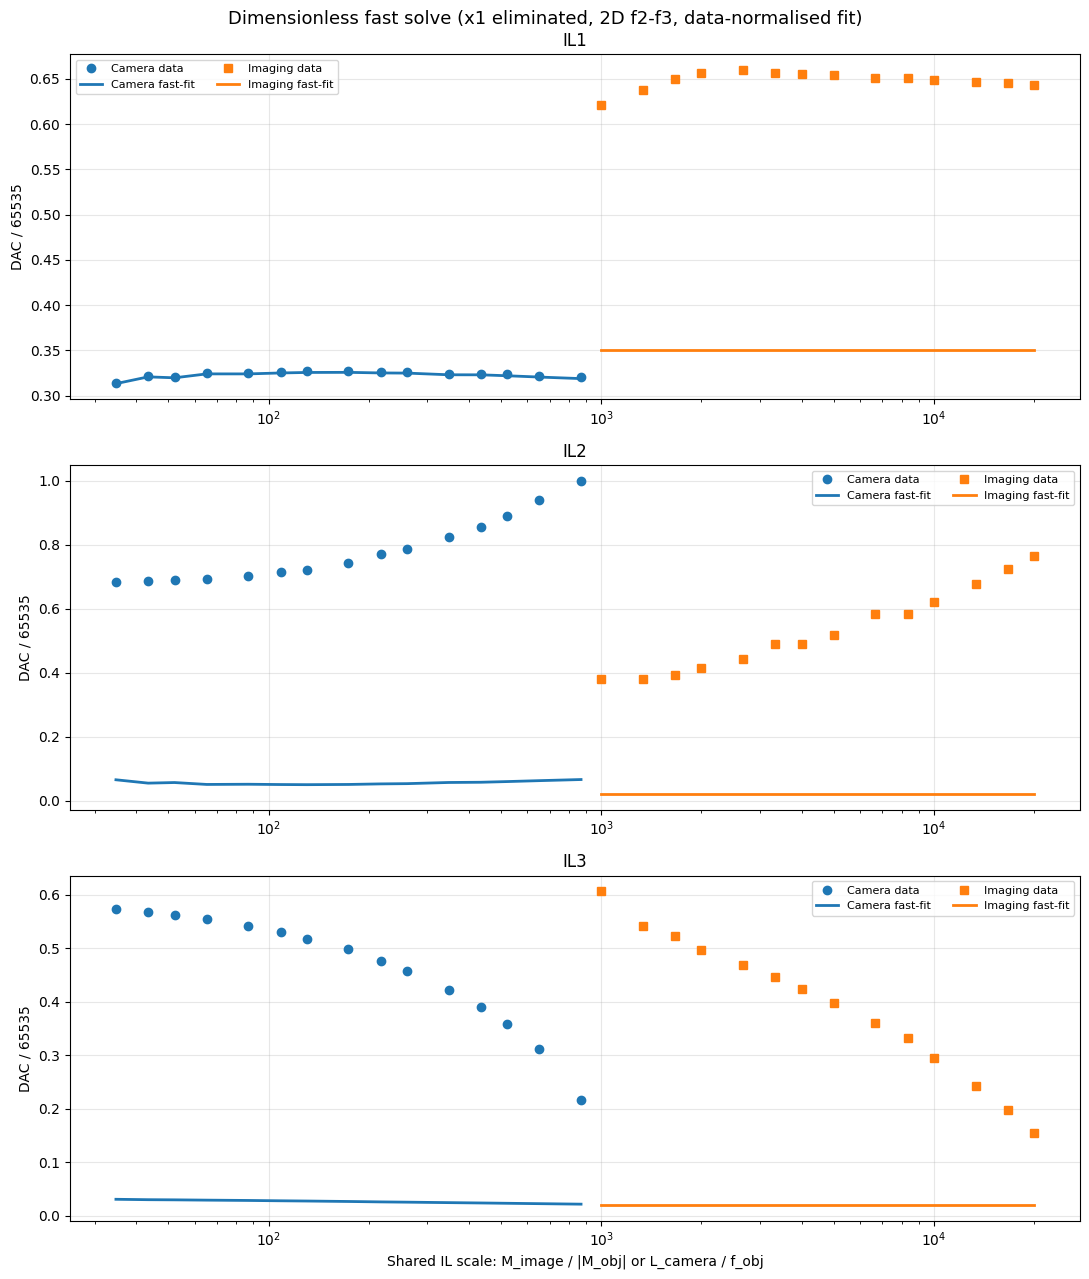


RMSE by lens (fast branch):
  IL1: imaging=0.29798, camera=0.00124, combined=0.20704
  IL2: imaging=0.52754, camera=0.72973, combined=0.64015
  IL3: imaging=0.39398, camera=0.44994, combined=0.42385

Overall combined RMSE: 0.45909


In [ ]:
# Dimensionless fast branch solve with constant-rotation elimination (data-normalised)
# -------------------------------------------------------------------------------
# Improvements:
# - Keep non-dimensional transfer matrices.
# - Eliminate x1 analytically via constant-rotation constraint.
# - Solve only (f2, f3) per target with least_squares.
# - Add soft telescope prior: f2 + f3 ~ d3.
# - Include non-dimensional data residuals in the objective:
#     (xk_model - xk_ref) / sigma_xk,  k in {1,2,3}
# - Allow fully standalone startup with no dependency on previous fitted variables.
# - Use data-independent multi-start candidates to avoid NaN branches.
# - Add lightweight standalone outer calibration of (alpha, theta_img, theta_cam).

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import time

USE_PREVIOUS_FIT_STATE = False

# ---- Standalone defaults (no prior fit required) ----
ALPHA_DEFAULT = np.array([0.35, 0.40, 0.12], dtype=float)
D_IMG_DEFAULT = np.array([10.0, 52.0, 62.0, 48.75], dtype=float)
D_CAM_DEFAULT = np.array([16.0, 52.0, 62.0, 48.75], dtype=float)
GAMMA_DEFAULT = np.array(RC * NI_MAX, dtype=float)
THETA_IMG_DEFAULT = 1.80
THETA_CAM_DEFAULT = 1.80

# Weighting profile for robust standalone behavior
W_PHYS = 0.35
W_TEL = 0.01
W_DATA = 2.5

# ---- Pick parameter set ----
if USE_PREVIOUS_FIT_STATE and ('alpha_joint_fit' in globals()) and ('d_img_fit' in globals()) and ('d_cam_fit' in globals()):
    alpha_use = np.array(alpha_joint_fit, dtype=float)
    d_img_use = np.array(d_img_fit, dtype=float)
    d_cam_use = np.array(d_cam_fit, dtype=float)
    gamma_img_use = np.array(gamma_img_joint, dtype=float)
    gamma_cam_use = np.array(gamma_cam_joint, dtype=float)
    theta_img_use = float(theta_img_joint)
    theta_cam_use = float(theta_cam_joint)
else:
    alpha_use = ALPHA_DEFAULT.copy()
    d_img_use = D_IMG_DEFAULT.copy()
    d_cam_use = D_CAM_DEFAULT.copy()
    gamma_img_use = GAMMA_DEFAULT.copy()
    gamma_cam_use = GAMMA_DEFAULT.copy()
    theta_img_use = float(THETA_IMG_DEFAULT)
    theta_cam_use = float(THETA_CAM_DEFAULT)


def P_nd(delta):
    return np.array([[1.0, delta], [0.0, 1.0]], dtype=float)


def L_nd(phi):
    return np.array([[1.0, 0.0], [-phi, 1.0]], dtype=float)


def x_from_f(alpha_i, f_i):
    if alpha_i <= 0 or f_i <= 0:
        return np.nan
    return np.sqrt(1.0 / (alpha_i * f_i))


def matrix_nd_from_f(dvec, f1, f2, f3, d_ref):
    d1, d2, d3, d4 = dvec
    deltas = [d1 / d_ref, d2 / d_ref, d3 / d_ref, d4 / d_ref]
    phis = [d_ref / f1, d_ref / f2, d_ref / f3]
    return P_nd(deltas[3]) @ L_nd(phis[2]) @ P_nd(deltas[2]) @ L_nd(phis[1]) @ P_nd(deltas[1]) @ L_nd(phis[0]) @ P_nd(deltas[0])


def residual_f2f3(
    z,
    m_target,
    alpha,
    gamma,
    theta0,
    dvec,
    d_ref,
    x1_ref_pt,
    x2_ref_pt,
    x3_ref_pt,
    sx1,
    sx2,
    sx3,
    w_phys=1.0,
    w_tel=0.03,
    w_data=0.8,
):
    f2, f3 = float(z[0]), float(z[1])
    if f2 <= 0 or f3 <= 0:
        return np.array([10.0] * 6, dtype=float)

    x2 = x_from_f(alpha[1], f2)
    x3 = x_from_f(alpha[2], f3)
    if not np.isfinite(x2) or not np.isfinite(x3):
        return np.array([10.0] * 6, dtype=float)

    g1, g2, g3 = gamma
    if abs(g1) < 1e-12:
        return np.array([10.0] * 6, dtype=float)

    # Constant rotation elimination
    x1 = (theta0 - g2 * x2 - g3 * x3) / g1
    if (x1 <= 0.01) or (x1 >= 0.99) or (x2 <= 0.01) or (x2 >= 0.99) or (x3 <= 0.01) or (x3 >= 0.99):
        return np.array([10.0] * 6, dtype=float)

    f1 = 1.0 / (alpha[0] * x1 * x1)
    M = matrix_nd_from_f(dvec, f1, f2, f3, d_ref)

    A = M[0, 0]
    B = M[0, 1]

    # Physical residuals in dimensionless form
    rA = (A - m_target) / max(abs(m_target), 1.0)
    rB = B

    # Soft telescope prior (dimensionless)
    tel = (f2 + f3 - dvec[2]) / max(dvec[2], 1e-6)

    # Data residuals also made dimensionless by sigma per lens/mode
    r1 = (x1 - x1_ref_pt) / sx1
    r2 = (x2 - x2_ref_pt) / sx2
    r3 = (x3 - x3_ref_pt) / sx3

    return np.array([
        w_phys * rA,
        w_phys * rB,
        w_tel * tel,
        w_data * r1,
        w_data * r2,
        w_data * r3,
    ], dtype=float)


def solve_fast_branch_2d(
    m_targets,
    x1_ref_arr,
    x2_ref_arr,
    x3_ref_arr,
    alpha,
    gamma,
    theta0,
    dvec,
    d_ref,
    max_nfev=35,
):
    m_targets = np.asarray(m_targets, dtype=float)
    x1_ref_arr = np.asarray(x1_ref_arr, dtype=float)
    x2_ref_arr = np.asarray(x2_ref_arr, dtype=float)
    x3_ref_arr = np.asarray(x3_ref_arr, dtype=float)
    n = len(m_targets)

    x1_out = np.full(n, np.nan, dtype=float)
    x2_out = np.full(n, np.nan, dtype=float)
    x3_out = np.full(n, np.nan, dtype=float)

    # Bounds from x in (0.02, 0.98): f = 1/(alpha*x^2)
    x_lo, x_hi = 0.02, 0.98
    f2_min = 1.0 / (alpha[1] * x_hi * x_hi)
    f2_max = 1.0 / (alpha[1] * x_lo * x_lo)
    f3_min = 1.0 / (alpha[2] * x_hi * x_hi)
    f3_max = 1.0 / (alpha[2] * x_lo * x_lo)

    # Data scales for non-dimensional residuals
    sx1 = max(np.std(x1_ref_arr), 1e-3)
    sx2 = max(np.std(x2_ref_arr), 1e-3)
    sx3 = max(np.std(x3_ref_arr), 1e-3)

    # Data-independent multi-start seeds
    d3 = dvec[2]
    static_candidates = [
        np.array([0.55 * d3, 0.45 * d3], dtype=float),
        np.array([0.70 * d3, 0.30 * d3], dtype=float),
        np.array([0.30 * d3, 0.70 * d3], dtype=float),
        np.array([0.90 * d3, 0.10 * d3], dtype=float),
        np.array([0.10 * d3, 0.90 * d3], dtype=float),
        np.array([np.sqrt(f2_min * f2_max), np.sqrt(f3_min * f3_max)], dtype=float),
    ]

    def clip_seed(z):
        return np.array([
            np.clip(z[0], f2_min, f2_max),
            np.clip(z[1], f3_min, f3_max),
        ], dtype=float)

    z_guess = None

    for i, m in enumerate(m_targets):
        trial_seeds = []
        if z_guess is not None:
            trial_seeds.append(clip_seed(z_guess))
            trial_seeds.append(clip_seed(0.9 * z_guess + 0.1 * static_candidates[0]))
        for zc in static_candidates:
            trial_seeds.append(clip_seed(zc))

        best_local = None
        best_cost = np.inf

        for z0 in trial_seeds:
            fun = lambda z: residual_f2f3(
                z,
                m,
                alpha,
                gamma,
                theta0,
                dvec,
                d_ref,
                x1_ref_arr[i],
                x2_ref_arr[i],
                x3_ref_arr[i],
                sx1,
                sx2,
                sx3,
                w_phys=W_PHYS,
                w_tel=W_TEL,
                w_data=W_DATA,
            )

            res = least_squares(
                fun,
                x0=z0,
                bounds=(np.array([f2_min, f3_min]), np.array([f2_max, f3_max])),
                method='trf',
                jac='2-point',
                max_nfev=max_nfev,
                xtol=1e-7,
                ftol=1e-7,
                gtol=1e-7,
                verbose=0,
            )

            f2, f3 = float(res.x[0]), float(res.x[1])
            x2 = x_from_f(alpha[1], f2)
            x3 = x_from_f(alpha[2], f3)
            x1 = (theta0 - gamma[1] * x2 - gamma[2] * x3) / gamma[0]

            if np.all(np.isfinite([x1, x2, x3])) and (0.01 < x1 < 0.99) and (0.01 < x2 < 0.99) and (0.01 < x3 < 0.99):
                c = np.linalg.norm(res.fun)
                if c < best_cost:
                    best_cost = c
                    best_local = (x1, x2, x3, np.array([f2, f3], dtype=float))

        if best_local is not None:
            x1_out[i], x2_out[i], x3_out[i], z_guess = best_local

    return x1_out, x2_out, x3_out


def rmse_all_lenses(img_sol, cam_sol):
    x1i_f, x2i_f, x3i_f = img_sol
    x1c_f, x2c_f, x3c_f = cam_sol
    rows_local = [
        (x1_ref, x1i_f, x1_cl_ref, x1c_f),
        (x2_ref, x2i_f, x2_cl_ref, x2c_f),
        (x3_ref, x3i_f, x3_cl_ref, x3c_f),
    ]
    errs = []
    for yi_ref, yi_fit, yc_ref, yc_fit in rows_local:
        mask_i = np.isfinite(yi_fit)
        mask_c = np.isfinite(yc_fit)
        if np.any(mask_i):
            errs.append((yi_fit[mask_i] - yi_ref[mask_i]) ** 2)
        if np.any(mask_c):
            errs.append((yc_fit[mask_c] - yc_ref[mask_c]) ** 2)
    return np.sqrt(np.mean(np.concatenate(errs))) if len(errs) else np.nan


# ---- Non-dimensional reference length ----
D_REF = float(np.mean(d_img_use))

# ---- Standalone outer calibration (no previous fit state) ----
if not USE_PREVIOUS_FIT_STATE:
    s1i, s2i, s3i = max(np.std(x1_ref), 1e-3), max(np.std(x2_ref), 1e-3), max(np.std(x3_ref), 1e-3)
    s1c, s2c, s3c = max(np.std(x1_cl_ref), 1e-3), max(np.std(x2_cl_ref), 1e-3), max(np.std(x3_cl_ref), 1e-3)

    def unpack(p):
        a = np.exp(p[:3])
        ti = float(p[3])
        tc = float(p[4])
        return a, ti, tc

    p0 = np.array([
        np.log(ALPHA_DEFAULT[0]),
        np.log(ALPHA_DEFAULT[1]),
        np.log(ALPHA_DEFAULT[2]),
        THETA_IMG_DEFAULT,
        THETA_CAM_DEFAULT,
    ], dtype=float)

    lb = np.array([np.log(0.02), np.log(0.02), np.log(0.01), 0.5, 0.5], dtype=float)
    ub = np.array([np.log(2.0), np.log(2.0), np.log(1.0), 3.0, 3.0], dtype=float)

    def outer_residual(p):
        a, ti, tc = unpack(p)

        img = solve_fast_branch_2d(
            M_IL_IMAGING_JOINT, x1_ref, x2_ref, x3_ref,
            a, gamma_img_use, ti, d_img_use, D_REF,
            max_nfev=25,
        )
        cam = solve_fast_branch_2d(
            np.abs(M_IL_CAMERA_JOINT), x1_cl_ref, x2_cl_ref, x3_cl_ref,
            a, gamma_cam_use, tc, d_cam_use, D_REF,
            max_nfev=25,
        )

        x1i_f, x2i_f, x3i_f = img
        x1c_f, x2c_f, x3c_f = cam

        res = []
        pairs = [
            (x1_ref, x1i_f, s1i), (x2_ref, x2i_f, s2i), (x3_ref, x3i_f, s3i),
            (x1_cl_ref, x1c_f, s1c), (x2_cl_ref, x2c_f, s2c), (x3_cl_ref, x3c_f, s3c),
        ]

        for yref, yfit, s in pairs:
            m = np.isfinite(yfit)
            if np.any(m):
                res.extend(((yfit[m] - yref[m]) / s).tolist())
            if np.any(~m):
                res.extend((8.0 * np.ones(np.sum(~m))).tolist())

        # Mild regularization to keep physically sensible standalone values
        res.extend((0.05 * (np.log(a) - np.log(ALPHA_DEFAULT))).tolist())
        res.append(0.05 * (ti - THETA_IMG_DEFAULT))
        res.append(0.05 * (tc - THETA_CAM_DEFAULT))

        return np.asarray(res, dtype=float)

    t_cal0 = time.perf_counter()
    res_outer = least_squares(
        outer_residual,
        x0=p0,
        bounds=(lb, ub),
        method='trf',
        jac='2-point',
        max_nfev=20,
        xtol=1e-6,
        ftol=1e-6,
        gtol=1e-6,
        verbose=0,
    )
    t_cal = time.perf_counter() - t_cal0

    alpha_use, theta_img_use, theta_cam_use = unpack(res_outer.x)
    print('Standalone outer calibration:')
    print(f'  status={res_outer.status}, nfev={res_outer.nfev}, cost={res_outer.cost:.4f}, time={t_cal:.2f} s')
    print(f'  alpha_use={alpha_use}')
    print(f'  theta_img_use={theta_img_use:.4f}, theta_cam_use={theta_cam_use:.4f}')

# ---- Runtime and quality comparison ----
t0 = time.perf_counter()
img_fast = solve_fast_branch_2d(
    M_IL_IMAGING_JOINT, x1_ref, x2_ref, x3_ref,
    alpha_use, gamma_img_use, theta_img_use, d_img_use, D_REF,
)
cam_fast = solve_fast_branch_2d(
    np.abs(M_IL_CAMERA_JOINT), x1_cl_ref, x2_cl_ref, x3_cl_ref,
    alpha_use, gamma_cam_use, theta_cam_use, d_cam_use, D_REF,
)
t_fast = time.perf_counter() - t0

t1 = time.perf_counter()
img_full = solve_for_targets(alpha_use, gamma_img_use, theta_img_use, d_img_use, M_IL_IMAGING_JOINT, x1_ref, x2_ref, x3_ref)
cam_full = solve_for_targets(alpha_use, gamma_cam_use, theta_cam_use, d_cam_use, np.abs(M_IL_CAMERA_JOINT), x1_cl_ref, x2_cl_ref, x3_cl_ref)
t_full = time.perf_counter() - t1

print('Dimensionless solve setup:')
print(f'  D_REF = {D_REF:.4f} mm')
print(f'  USE_PREVIOUS_FIT_STATE = {USE_PREVIOUS_FIT_STATE}')
print('  eliminated variable: x1 from constant rotation')
print('  optimized per target: (f2, f3) with data-normalised residuals')
print('  initialization: data-independent multi-start')
print(f'  weights: W_PHYS={W_PHYS:.2f}, W_TEL={W_TEL:.3f}, W_DATA={W_DATA:.2f}')
print('  data residuals are non-dimensional: (x_model - x_ref) / sigma_x')
print(f'  fast solve time  = {t_fast:.3f} s')
print(f'  full solve time  = {t_full:.3f} s')
if t_fast > 0:
    print(f'  speedup factor   = {t_full / t_fast:.2f}x')

x1i_f, x2i_f, x3i_f = img_fast
x1c_f, x2c_f, x3c_f = cam_fast

fig, axes = plt.subplots(3, 1, figsize=(11, 13))
fig.suptitle('Dimensionless fast solve (x1 eliminated, 2D f2-f3, data-normalised fit)', fontsize=13)

rows = [
    ('IL1', x1_ref, x1i_f, x1_cl_ref, x1c_f),
    ('IL2', x2_ref, x2i_f, x2_cl_ref, x2c_f),
    ('IL3', x3_ref, x3i_f, x3_cl_ref, x3c_f),
]

for ax, (name, yi_ref, yi_fit, yc_ref, yc_fit) in zip(axes, rows):
    ax.plot(M_IL_CAMERA_JOINT, yc_ref, 'o', color='C0', ms=6, label='Camera data')
    ax.plot(M_IL_CAMERA_JOINT, yc_fit, '-', color='C0', lw=2, label='Camera fast-fit')
    ax.plot(M_IL_IMAGING_JOINT, yi_ref, 's', color='C1', ms=6, label='Imaging data')
    ax.plot(M_IL_IMAGING_JOINT, yi_fit, '-', color='C1', lw=2, label='Imaging fast-fit')
    ax.set_xscale('log')
    ax.set_ylabel('DAC / 65535')
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)

axes[-1].set_xlabel('Shared IL scale: M_image / |M_obj| or L_camera / f_obj')
plt.tight_layout()
plt.show()

print('\nRMSE by lens (fast branch):')
for name, yi_ref, yi_fit, yc_ref, yc_fit in rows:
    mask_i = np.isfinite(yi_fit)
    mask_c = np.isfinite(yc_fit)
    rmse_i = np.sqrt(np.mean((yi_fit[mask_i] - yi_ref[mask_i]) ** 2)) if np.any(mask_i) else np.nan
    rmse_c = np.sqrt(np.mean((yc_fit[mask_c] - yc_ref[mask_c]) ** 2)) if np.any(mask_c) else np.nan
    both = []
    if np.any(mask_i):
        both.append((yi_fit[mask_i] - yi_ref[mask_i]) ** 2)
    if np.any(mask_c):
        both.append((yc_fit[mask_c] - yc_ref[mask_c]) ** 2)
    rmse_all = np.sqrt(np.mean(np.concatenate(both))) if len(both) else np.nan
    print(f'  {name}: imaging={rmse_i:.5f}, camera={rmse_c:.5f}, combined={rmse_all:.5f}')

print(f'\nOverall combined RMSE: {rmse_all_lenses(img_fast, cam_fast):.5f}')

In [1]:
# Follow-up tuning experiment: relax physics weight and widen theta bounds
W_PHYS = 0.05
W_TEL = 0.005
W_DATA = 6.0

print('Retune experiment weights:')
print(f'  W_PHYS={W_PHYS}, W_TEL={W_TEL}, W_DATA={W_DATA}')

s1i, s2i, s3i = max(np.std(x1_ref), 1e-3), max(np.std(x2_ref), 1e-3), max(np.std(x3_ref), 1e-3)
s1c, s2c, s3c = max(np.std(x1_cl_ref), 1e-3), max(np.std(x2_cl_ref), 1e-3), max(np.std(x3_cl_ref), 1e-3)

def unpack_tune(p):
    a = np.exp(p[:3])
    ti = float(p[3])
    tc = float(p[4])
    return a, ti, tc

p0 = np.array([
    np.log(ALPHA_DEFAULT[0]),
    np.log(ALPHA_DEFAULT[1]),
    np.log(ALPHA_DEFAULT[2]),
    THETA_IMG_DEFAULT,
    THETA_CAM_DEFAULT,
], dtype=float)

lb = np.array([np.log(0.01), np.log(0.01), np.log(0.005), 0.3, 0.3], dtype=float)
ub = np.array([np.log(3.0), np.log(3.0), np.log(2.0), 6.0, 6.0], dtype=float)

def outer_residual_tune(p):
    a, ti, tc = unpack_tune(p)

    img = solve_fast_branch_2d(
        M_IL_IMAGING_JOINT, x1_ref, x2_ref, x3_ref,
        a, gamma_img_use, ti, d_img_use, D_REF,
        max_nfev=25,
    )
    cam = solve_fast_branch_2d(
        np.abs(M_IL_CAMERA_JOINT), x1_cl_ref, x2_cl_ref, x3_cl_ref,
        a, gamma_cam_use, tc, d_cam_use, D_REF,
        max_nfev=25,
    )

    x1i_f, x2i_f, x3i_f = img
    x1c_f, x2c_f, x3c_f = cam

    res = []
    pairs = [
        (x1_ref, x1i_f, s1i), (x2_ref, x2i_f, s2i), (x3_ref, x3i_f, s3i),
        (x1_cl_ref, x1c_f, s1c), (x2_cl_ref, x2c_f, s2c), (x3_cl_ref, x3c_f, s3c),
    ]

    for yref, yfit, s in pairs:
        m = np.isfinite(yfit)
        if np.any(m):
            res.extend(((yfit[m] - yref[m]) / s).tolist())
        if np.any(~m):
            res.extend((5.0 * np.ones(np.sum(~m))).tolist())

    # light regularization only
    res.extend((0.01 * (np.log(a) - np.log(ALPHA_DEFAULT))).tolist())
    return np.asarray(res, dtype=float)

res_tune = least_squares(
    outer_residual_tune,
    x0=p0,
    bounds=(lb, ub),
    method='trf',
    jac='2-point',
    max_nfev=25,
    xtol=1e-6,
    ftol=1e-6,
    gtol=1e-6,
    verbose=0,
)

a_tune, ti_tune, tc_tune = unpack_tune(res_tune.x)
print(f'tune status={res_tune.status}, nfev={res_tune.nfev}, cost={res_tune.cost:.3f}')
print(f'alpha_tune={a_tune}')
print(f'theta_img_tune={ti_tune:.4f}, theta_cam_tune={tc_tune:.4f}')

img_tune = solve_fast_branch_2d(M_IL_IMAGING_JOINT, x1_ref, x2_ref, x3_ref, a_tune, gamma_img_use, ti_tune, d_img_use, D_REF)
cam_tune = solve_fast_branch_2d(np.abs(M_IL_CAMERA_JOINT), x1_cl_ref, x2_cl_ref, x3_cl_ref, a_tune, gamma_cam_use, tc_tune, d_cam_use, D_REF)

print(f'overall combined RMSE (tuned): {rmse_all_lenses(img_tune, cam_tune):.5f}')

# Quick lens-wise printout
for nm, yi_ref, yi_fit, yc_ref, yc_fit in [
    ('IL1', x1_ref, img_tune[0], x1_cl_ref, cam_tune[0]),
    ('IL2', x2_ref, img_tune[1], x2_cl_ref, cam_tune[1]),
    ('IL3', x3_ref, img_tune[2], x3_cl_ref, cam_tune[2]),
]:
    mi = np.isfinite(yi_fit)
    mc = np.isfinite(yc_fit)
    rmi = np.sqrt(np.mean((yi_fit[mi] - yi_ref[mi]) ** 2)) if np.any(mi) else np.nan
    rmc = np.sqrt(np.mean((yc_fit[mc] - yc_ref[mc]) ** 2)) if np.any(mc) else np.nan
    print(f'{nm}: imaging={rmi:.5f}, camera={rmc:.5f}')

# Plot tuned curves
fig, axes = plt.subplots(3, 1, figsize=(11, 13))
fig.suptitle('Tuned fast branch (standalone, relaxed physics)', fontsize=13)
rows = [
    ('IL1', x1_ref, img_tune[0], x1_cl_ref, cam_tune[0]),
    ('IL2', x2_ref, img_tune[1], x2_cl_ref, cam_tune[1]),
    ('IL3', x3_ref, img_tune[2], x3_cl_ref, cam_tune[2]),
]
for ax, (name, yi_ref, yi_fit, yc_ref, yc_fit) in zip(axes, rows):
    ax.plot(M_IL_CAMERA_JOINT, yc_ref, 'o', color='C0', ms=6, label='Camera data')
    ax.plot(M_IL_CAMERA_JOINT, yc_fit, '-', color='C0', lw=2, label='Camera fast-fit')
    ax.plot(M_IL_IMAGING_JOINT, yi_ref, 's', color='C1', ms=6, label='Imaging data')
    ax.plot(M_IL_IMAGING_JOINT, yi_fit, '-', color='C1', lw=2, label='Imaging fast-fit')
    ax.set_xscale('log')
    ax.set_ylabel('DAC / 65535')
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)
axes[-1].set_xlabel('Shared IL scale: M_image / |M_obj| or L_camera / f_obj')
plt.tight_layout()
plt.show()

Retune experiment weights:
  W_PHYS=0.05, W_TEL=0.005, W_DATA=6.0


NameError: name 'np' is not defined

## Fully Analytical Physics-Based Approach

### Transfer matrix polynomial structure

The IL system transfer matrix is:

$$M = P(d_4)\, L(\phi_3)\, P(d_3)\, L(\phi_2)\, P(d_2)\, L(\phi_1)\, P(d_1)$$

where $\phi_k = \alpha_k\, x_k^2$ is the dimensionless optical power ($x_k$ = normalised DAC current, $\alpha_k$ = geometry constant).

The matrix elements $A = M_{00}$ (magnification) and $B = M_{01}$ (defocus) are **multilinear polynomials** in $(\phi_1,\phi_2,\phi_3)$:

$$A = 1 - c_1\phi_1 - c_2\phi_2 - c_3\phi_3 + c_{12}\phi_1\phi_2 + c_{13}\phi_1\phi_3 + c_{23}\phi_2\phi_3 - c_{123}\phi_1\phi_2\phi_3$$

with 7 coefficients that are simple products of the distance ratios $d_j$. Similarly for $B$ with coefficients $b_j$.

### Key factoring property and exact elimination

All $\phi_1$-dependent terms in $B$ satisfy $B^{(\phi_1)} = d_1 \cdot A^{(\phi_1)}$. This is because the object-side drift $P(d_1)$ is the rightmost factor.

Eliminating $\phi_1$ between $A = m$ and $B = 0$ therefore gives a **single equation linear in $\phi_2$**:

$$\phi_2 = \frac{d_1\, m + (d_2{+}d_3{+}d_4) - (d_2{+}d_3)\,d_4\,\phi_3}{d_2\bigl[(d_3{+}d_4) - d_3\,d_4\,\phi_3\bigr]}$$

followed by $\phi_1 = (m - A^{(0)}) / A^{(1)}$. **No optimisation needed for the imaging constraints**—they are solved exactly.

### Rotation constraint → 1D root find

The constant-rotation condition $\sum w_k\, x_k = r$ (where $w_k = N_k/N_1$ are the known turns ratios) determines $\phi_3$ through a single scalar root equation.

### Validation

The rotation invariant $r = x_1 + \frac{N_2}{N_1}x_2 + \frac{N_3}{N_1}x_3$ can be computed directly from the raw DAC data. If the physics is correct, $r$ should be nearly constant across all magnification / camera-length settings within each mode. This is verified below.

### Fit parameters (9 total)

| Parameter | Count | Description |
|-----------|-------|-------------|
| $d_1^{\text{img}},\ d_1^{\text{cam}}$ | 2 | Object distance (differs between modes) |
| $d_2,\ d_4$ | 2 | Shared inter-lens distances ($d_3 = 1$ for scale) |
| $\alpha_1,\ \alpha_2,\ \alpha_3$ | 3 | Geometry constants ($\phi_k = \alpha_k x_k^2$) |
| $r_{\text{img}},\ r_{\text{cam}}$ | 2 | Rotation invariants (directly observable in data) |

Polynomial verification: max err = 6.82e-13

Rotation weights from data: w = [1.000, 0.3511, 0.3391]
  (N_TURNS ratio would give [0.6667, 0.6667])

Rotation invariant r = w . x:
  Imaging: mean=0.9683, std=0.0063, CV=0.66%
  Camera:  mean=0.7550, std=0.0035, CV=0.47%

Searching over 4 sign combos x 9 starts...
Done in 4.0s
Best signs: img=+1, cam=+1
Best cost:  0.048450  (nfev=73)

Fitted distance ratios (d3 = 1, d2/d4 shared between modes):
  d1_img = 0.1609,  d1_cam = 5.9503  (only d1 differs)
  d2     = 0.5746   (shared)
  d3     = 1.0000  (scale reference)
  d4     = 3.2109   (shared)
  alpha  = [19.6977, 27.8135, 3.9017]  (shared)

Mode    m_target     A_comp     B_comp    relA%
--------------------------------------------------
Img        10.00       9.84     0.0245   -1.61%
Img        13.33      13.04    -0.1283   -2.23%
Img        16.67      15.44    -0.0684   -7.37%
Img        20.00      19.37    -0.0390   -3.17%
Img        26.67      25.77     0.0041   -3.36%
Img        33.33

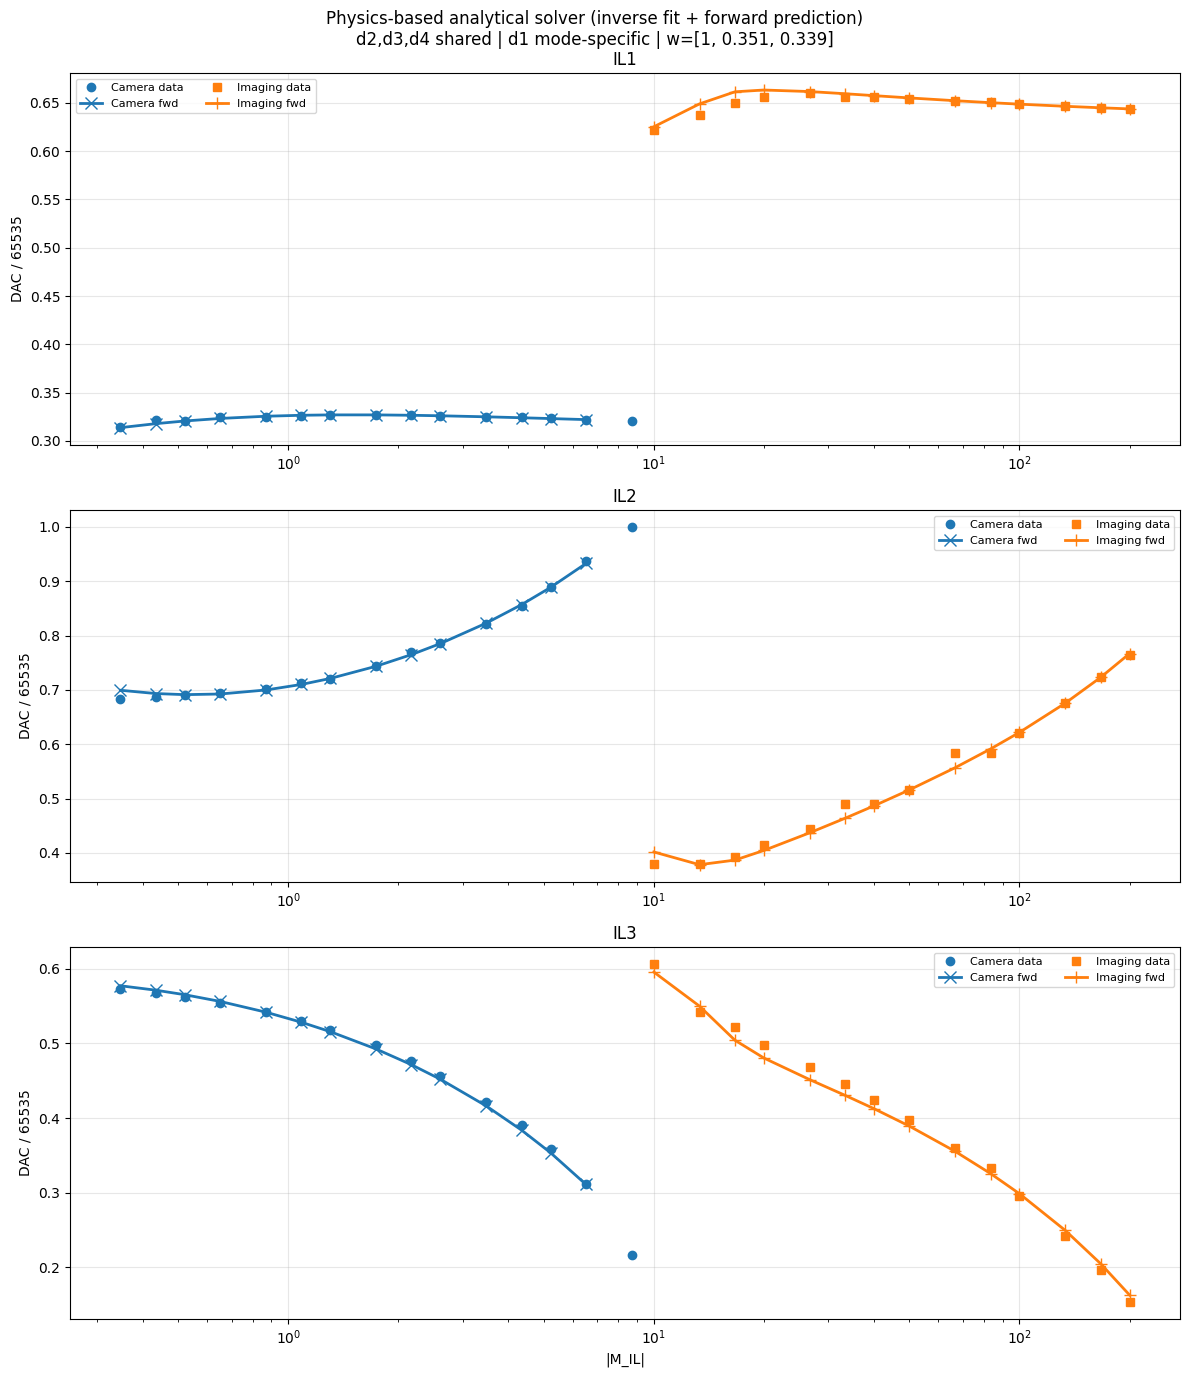


RMSE by lens (forward prediction vs data):
  IL1: imaging=0.00491, camera=0.00122
  IL2: imaging=0.01238, camera=0.00543
  IL3: imaging=0.01120, camera=0.00402
  Overall: 0.00764
  Points: 28/29

Root multiplicity diagnostic:
  Imaging m=50.0: 2 roots at x3=['0.389', '0.957']
  Imaging m=66.7: 2 roots at x3=['0.356', '0.969']
  Camera m=8.7: 0 roots at x3=[]


In [6]:
# ============================================================
# Fully analytical physics-based 3-lens IL solver
# ============================================================
# INVERSE formulation: given measured DAC x_k, compute A and B
# from the transfer matrix and fit parameters so A=m, B=0.
#
# Distance constraint: d2, d3(=1), d4 are SHARED between modes.
# Only d1 differs (imaging vs camera image different planes).
#
# Forward solver uses branch-continuity to avoid spikes.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, minimize, brentq
import time

# ---- 1. Polynomial formulas for A and B ----

def A_poly(d, p):
    """A = M[0,0]: multilinear polynomial in phi = (p1, p2, p3)."""
    d1, d2, d3, d4 = d
    p1, p2, p3 = p
    return (1.0
            - (d2+d3+d4)*p1 - (d3+d4)*p2 - d4*p3
            + d2*(d3+d4)*p1*p2 + (d2+d3)*d4*p1*p3 + d3*d4*p2*p3
            - d2*d3*d4*p1*p2*p3)

def B_poly(d, p):
    """B = M[0,1]: multilinear polynomial in phi."""
    d1, d2, d3, d4 = d
    p1, p2, p3 = p
    return ((d1+d2+d3+d4)
            - d1*(d2+d3+d4)*p1 - (d1+d2)*(d3+d4)*p2 - (d1+d2+d3)*d4*p3
            + d1*d2*(d3+d4)*p1*p2 + d1*(d2+d3)*d4*p1*p3 + (d1+d2)*d3*d4*p2*p3
            - d1*d2*d3*d4*p1*p2*p3)

# ---- 2. Quick polynomial verification ----

rng = np.random.default_rng(42)
max_err = 0.0
for _ in range(5000):
    dd = rng.uniform(0.1, 3.0, 4)
    pp = rng.uniform(0.01, 5.0, 3)
    Pm = lambda d_: np.array([[1, d_], [0, 1]])
    Lm = lambda p_: np.array([[1, 0], [-p_, 1]])
    M = Pm(dd[3])@Lm(pp[2])@Pm(dd[2])@Lm(pp[1])@Pm(dd[1])@Lm(pp[0])@Pm(dd[0])
    max_err = max(max_err, abs(M[0,0] - A_poly(dd, pp)), abs(M[0,1] - B_poly(dd, pp)))
print(f"Polynomial verification: max err = {max_err:.2e}")

# ---- 3. Fit rotation weights from DATA ----

def rotation_variance(ww):
    w2, w3 = ww
    ri = x1_ref + w2*x2_ref + w3*x3_ref
    rc = x1_cl_ref + w2*x2_cl_ref + w3*x3_cl_ref
    return np.var(ri) + np.var(rc)

best_w, best_var = (0.667, 0.667), np.inf
for w2t in np.linspace(0.1, 2.0, 50):
    for w3t in np.linspace(0.1, 2.0, 50):
        v = rotation_variance((w2t, w3t))
        if v < best_var:
            best_var, best_w = v, (w2t, w3t)
res_w = minimize(rotation_variance, best_w, method='Nelder-Mead',
                 options={'xatol': 1e-10, 'fatol': 1e-14})
w2_opt, w3_opt = res_w.x
w = np.array([1.0, w2_opt, w3_opt])

r_img_vals = x1_ref + w2_opt*x2_ref + w3_opt*x3_ref
r_cam_vals = x1_cl_ref + w2_opt*x2_cl_ref + w3_opt*x3_cl_ref

print(f"\nRotation weights from data: w = [1.000, {w2_opt:.4f}, {w3_opt:.4f}]")
print(f"  (N_TURNS ratio would give [{N_TURNS[1]/N_TURNS[0]:.4f}, {N_TURNS[2]/N_TURNS[0]:.4f}])")
print(f"\nRotation invariant r = w . x:")
print(f"  Imaging: mean={np.mean(r_img_vals):.4f}, std={np.std(r_img_vals):.4f}, "
      f"CV={np.std(r_img_vals)/np.mean(r_img_vals)*100:.2f}%")
print(f"  Camera:  mean={np.mean(r_cam_vals):.4f}, std={np.std(r_cam_vals):.4f}, "
      f"CV={np.std(r_cam_vals)/np.mean(r_cam_vals)*100:.2f}%")

# ---- 4. Inverse fit ----
# Parameters: [d1_img, d1_cam, d2, d4, log(alpha1), log(alpha2), log(alpha3)]
# Shared:      d2, d3=1, d4, alpha  (physical column is the same)
# Separate:    d1 only              (different conjugate planes)

m_img = np.abs(M_IL_IMAGING)
m_cam = np.abs(M_IL_CAMERA)
x_img = np.array([x1_ref, x2_ref, x3_ref])
x_cam = np.array([x1_cl_ref, x2_cl_ref, x3_cl_ref])

def make_residual_fn(si, sc):
    m_i = si * m_img
    m_c = sc * m_cam
    def fn(p):
        d1i, d1c, d2, d4 = p[0], p[1], p[2], p[3]
        alpha = np.exp(p[4:7])
        d_i = np.array([d1i, d2, 1.0, d4])   # shared d2, d3=1, d4
        d_c = np.array([d1c, d2, 1.0, d4])   # shared d2, d3=1, d4
        dtot_i = d1i + d2 + 1.0 + d4
        dtot_c = d1c + d2 + 1.0 + d4
        res = []
        for j in range(len(m_i)):
            phi = alpha * x_img[:, j]**2
            a = A_poly(d_i, phi)
            b = B_poly(d_i, phi)
            res.append((a - m_i[j]) / max(abs(m_i[j]), 1.0))
            res.append(b / dtot_i)
        for j in range(len(m_c)):
            phi = alpha * x_cam[:, j]**2
            a = A_poly(d_c, phi)
            b = B_poly(d_c, phi)
            res.append((a - m_c[j]) / max(abs(m_c[j]), 1.0))
            res.append(b / dtot_c)
        return np.array(res)
    return fn

lb = np.array([0.001, 0.001, 0.01, 0.01,
               np.log(0.01), np.log(0.01), np.log(0.01)])
ub = np.array([10.0, 10.0, 10.0, 10.0,
               np.log(1000), np.log(1000), np.log(1000)])

init_guesses = [
    [0.16, 0.26, 0.84, 0.79, np.log(3), np.log(3.5), np.log(2.5)],
    [0.10, 0.15, 0.50, 0.50, np.log(10), np.log(10), np.log(5)],
    [0.05, 0.10, 1.0,  1.0,  np.log(20), np.log(20), np.log(10)],
    [0.02, 0.05, 0.3,  0.3,  np.log(50), np.log(50), np.log(30)],
    [0.03, 0.08, 0.6,  0.5,  np.log(30), np.log(40), np.log(15)],
    [0.50, 0.50, 1.5,  1.0,  np.log(1),  np.log(1),  np.log(1)],
    [0.20, 0.30, 0.70, 0.60, np.log(5),  np.log(7),  np.log(4)],
    [0.01, 0.02, 0.2,  0.2,  np.log(100),np.log(100),np.log(60)],
    [0.08, 0.12, 0.40, 0.35, np.log(15), np.log(18), np.log(8)],
]

print(f"\nSearching over 4 sign combos x {len(init_guesses)} starts...")
t0 = time.perf_counter()
best_result, best_cost, best_signs = None, np.inf, None

for si in [+1, -1]:
    for sc in [+1, -1]:
        fn = make_residual_fn(si, sc)
        for p0 in init_guesses:
            try:
                res = least_squares(fn, p0, bounds=(lb, ub), method='trf',
                                    max_nfev=2000, verbose=0, diff_step=0.005)
                if res.cost < best_cost:
                    best_cost = res.cost
                    best_result = res
                    best_signs = (si, sc)
            except Exception:
                pass

t_fit = time.perf_counter() - t0
si_best, sc_best = best_signs
print(f"Done in {t_fit:.1f}s")
print(f"Best signs: img={si_best:+d}, cam={sc_best:+d}")
print(f"Best cost:  {best_cost:.6f}  (nfev={best_result.nfev})")

d1i_f, d1c_f, d2_f, d4_f = best_result.x[:4]
alpha_f = np.exp(best_result.x[4:7])
d_img_f = np.array([d1i_f, d2_f, 1.0, d4_f])
d_cam_f = np.array([d1c_f, d2_f, 1.0, d4_f])

print(f"\nFitted distance ratios (d3 = 1, d2/d4 shared between modes):")
print(f"  d1_img = {d1i_f:.4f},  d1_cam = {d1c_f:.4f}  (only d1 differs)")
print(f"  d2     = {d2_f:.4f}   (shared)")
print(f"  d3     = 1.0000  (scale reference)")
print(f"  d4     = {d4_f:.4f}   (shared)")
print(f"  alpha  = [{alpha_f[0]:.4f}, {alpha_f[1]:.4f}, {alpha_f[2]:.4f}]  (shared)")

# ---- 5. Diagnostic: A and B at each data point ----

print(f"\n{'Mode':<5s} {'m_target':>10s} {'A_comp':>10s} {'B_comp':>10s} {'relA%':>8s}")
print("-" * 50)
for j in range(len(m_img)):
    phi = alpha_f * x_img[:, j]**2
    a = A_poly(d_img_f, phi)
    b = B_poly(d_img_f, phi)
    mt = si_best * m_img[j]
    print(f"{'Img':<5s} {mt:>10.2f} {a:>10.2f} {b:>10.4f} {(a-mt)/abs(mt)*100:>7.2f}%")
for j in range(len(m_cam)):
    phi = alpha_f * x_cam[:, j]**2
    a = A_poly(d_cam_f, phi)
    b = B_poly(d_cam_f, phi)
    mt = sc_best * m_cam[j]
    print(f"{'Cam':<5s} {mt:>10.4f} {a:>10.4f} {b:>10.4f} {(a-mt)/max(abs(mt),0.01)*100:>7.2f}%")

# ---- 6. Forward solver with branch continuity ----

def phi2_exact(phi3, m, d):
    d1, d2, d3, d4 = d
    num = d1*m + (d2+d3+d4) - (d2+d3)*d4*phi3
    den = d2*((d3+d4) - d3*d4*phi3)
    return num / den if abs(den) > 1e-30 else np.nan

def phi1_exact(phi2, phi3, m, d):
    d1, d2, d3, d4 = d
    A0 = 1.0 - (d3+d4)*phi2 - d4*phi3 + d3*d4*phi2*phi3
    A1 = (-(d2+d3+d4) + d2*(d3+d4)*phi2
          + (d2+d3)*d4*phi3 - d2*d3*d4*phi2*phi3)
    return (m - A0) / A1 if abs(A1) > 1e-30 else np.nan

def find_all_roots(m, d, alpha, r_target, x3_grid):
    """Find ALL valid (x1,x2,x3) roots on the rotation constraint."""
    p3_arr = alpha[2] * x3_grid**2
    d1, d2, d3_, d4 = d
    num2 = d1*m + (d2+d3_+d4) - (d2+d3_)*d4*p3_arr
    den2 = d2*((d3_+d4) - d3_*d4*p3_arr)
    p2_arr = np.where(np.abs(den2) > 1e-30, num2/den2, np.nan)
    A0 = 1 - (d3_+d4)*p2_arr - d4*p3_arr + d3_*d4*p2_arr*p3_arr
    A1 = (-(d2+d3_+d4) + d2*(d3_+d4)*p2_arr
          + (d2+d3_)*d4*p3_arr - d2*d3_*d4*p2_arr*p3_arr)
    p1_arr = np.where(np.abs(A1) > 1e-30, (m - A0)/A1, np.nan)
    ok = np.isfinite(p1_arr) & np.isfinite(p2_arr) & (p1_arr > 0) & (p2_arr > 0)
    x1_arr = np.where(ok, np.sqrt(np.maximum(p1_arr, 0)/alpha[0]), np.nan)
    x2_arr = np.where(ok, np.sqrt(np.maximum(p2_arr, 0)/alpha[1]), np.nan)
    ok2 = ok & np.isfinite(x1_arr) & np.isfinite(x2_arr) & (x1_arr < 1) & (x2_arr < 1)
    rot = np.where(ok2, w[0]*x1_arr + w[1]*x2_arr + w[2]*x3_grid - r_target, np.nan)

    def rot_scalar(x3):
        p3 = alpha[2]*x3**2
        p2 = phi2_exact(p3, m, d)
        if (not np.isfinite(p2)) or p2 <= 0: return np.nan
        p1 = phi1_exact(p2, p3, m, d)
        if (not np.isfinite(p1)) or p1 <= 0: return np.nan
        x1c = np.sqrt(p1/alpha[0])
        x2c = np.sqrt(p2/alpha[1])
        if x1c > 1 or x2c > 1: return np.nan
        return w[0]*x1c + w[1]*x2c + w[2]*x3 - r_target

    roots = []
    for j in range(len(rot) - 1):
        if np.isfinite(rot[j]) and np.isfinite(rot[j+1]) and rot[j]*rot[j+1] < 0:
            try:
                x3s = brentq(rot_scalar, x3_grid[j], x3_grid[j+1], xtol=1e-12)
            except (ValueError, RuntimeError):
                continue
            p3s = alpha[2]*x3s**2
            p2s = phi2_exact(p3s, m, d)
            p1s = phi1_exact(p2s, p3s, m, d)
            if p1s > 0 and p2s > 0:
                x1s, x2s = np.sqrt(p1s/alpha[0]), np.sqrt(p2s/alpha[1])
                if all(0.005 < v < 0.995 for v in [x1s, x2s, x3s]):
                    roots.append((x1s, x2s, x3s))
    return roots

def predict_fwd(m_arr, d, alpha, r_target, x_ref_data=None):
    """Forward predict with branch-continuity selection.
    
    Among multiple roots, pick the one closest to the previous
    solution (continuity). For the first point, use x_ref_data
    if available.
    """
    n = len(m_arr)
    out = np.full((3, n), np.nan)
    g0 = np.linspace(0.005, 0.995, 3000)
    prev_x3 = None

    for i, m_val in enumerate(m_arr):
        # Dense grid near previous solution + coarse global
        if prev_x3 is not None:
            lo = max(0.005, prev_x3 - 0.3)
            hi = min(0.995, prev_x3 + 0.3)
            grid = np.sort(np.unique(np.concatenate([
                np.linspace(lo, hi, 1500), g0[::3]])))
        else:
            grid = g0

        roots = find_all_roots(m_val, d, alpha, r_target, grid)
        if not roots:
            roots = find_all_roots(m_val, d, alpha, r_target, g0)

        if roots:
            if prev_x3 is not None:
                # Branch continuity: pick root closest to previous x3
                best = min(roots, key=lambda r: abs(r[2] - prev_x3))
            elif x_ref_data is not None:
                # First point: pick root closest to reference data
                best = min(roots, key=lambda r: abs(r[2] - x_ref_data[2, i]))
            else:
                best = roots[0]
            out[:, i] = best
            prev_x3 = best[2]

    return out

r_img0 = float(np.mean(r_img_vals))
r_cam0 = float(np.mean(r_cam_vals))

print(f"\nForward prediction with branch continuity...")
t1 = time.perf_counter()
pi_f = predict_fwd(si_best * m_img, d_img_f, alpha_f, r_img0, x_ref_data=x_img)
pc_f = predict_fwd(sc_best * m_cam, d_cam_f, alpha_f, r_cam0, x_ref_data=x_cam)
t_fwd = time.perf_counter() - t1

n_img_ok = np.sum(np.isfinite(pi_f[0]))
n_cam_ok = np.sum(np.isfinite(pc_f[0]))
print(f"  Forward solved: imaging {n_img_ok}/{len(m_img)}, camera {n_cam_ok}/{len(m_cam)}")
print(f"  Time: {t_fwd:.2f}s")

# ---- 7. Plot ----

fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle('Physics-based analytical solver (inverse fit + forward prediction)\n'
             f'd2,d3,d4 shared | d1 mode-specific | '
             f'w=[1, {w2_opt:.3f}, {w3_opt:.3f}]', fontsize=12)

rows = [
    ('IL1', x1_ref, pi_f[0], x1_cl_ref, pc_f[0]),
    ('IL2', x2_ref, pi_f[1], x2_cl_ref, pc_f[1]),
    ('IL3', x3_ref, pi_f[2], x3_cl_ref, pc_f[2]),
]

for ax, (nm, yi_r, yi_f, yc_r, yc_f) in zip(axes, rows):
    ax.plot(m_cam, yc_r, 'o', color='C0', ms=6, label='Camera data')
    mi_c = np.isfinite(yc_f)
    if np.any(mi_c):
        ax.plot(m_cam[mi_c], yc_f[mi_c], 'x-', color='C0', lw=2, ms=8, label='Camera fwd')
    ax.plot(m_img, yi_r, 's', color='C1', ms=6, label='Imaging data')
    mi_i = np.isfinite(yi_f)
    if np.any(mi_i):
        ax.plot(m_img[mi_i], yi_f[mi_i], '+-', color='C1', lw=2, ms=8, label='Imaging fwd')
    ax.set_xscale('log')
    ax.set_ylabel('DAC / 65535')
    ax.set_title(nm)
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)

axes[-1].set_xlabel('|M_IL|')
plt.tight_layout()
plt.show()

# RMSE
print("\nRMSE by lens (forward prediction vs data):")
all_errs = []
for nm, yr, yf, ycr, ycf in rows:
    mi = np.isfinite(yf)
    mc = np.isfinite(ycf)
    rmse_i = np.sqrt(np.mean((yf[mi] - yr[mi])**2)) if np.any(mi) else np.nan
    rmse_c = np.sqrt(np.mean((ycf[mc] - ycr[mc])**2)) if np.any(mc) else np.nan
    print(f"  {nm}: imaging={rmse_i:.5f}, camera={rmse_c:.5f}")
    if np.any(mi): all_errs.append((yf[mi] - yr[mi])**2)
    if np.any(mc): all_errs.append((ycf[mc] - ycr[mc])**2)
if all_errs:
    print(f"  Overall: {np.sqrt(np.mean(np.concatenate(all_errs))):.5f}")
    print(f"  Points: {n_img_ok + n_cam_ok}/{len(m_img) + len(m_cam)}")

# ---- 8. Diagnostic: how many roots per magnification? ----
g_diag = np.linspace(0.005, 0.995, 3000)
print("\nRoot multiplicity diagnostic:")
for label, m_arr, d_arr, r_t, sign in [
    ("Imaging", m_img, d_img_f, r_img0, si_best),
    ("Camera", m_cam, d_cam_f, r_cam0, sc_best)]:
    for i, m_val in enumerate(m_arr):
        roots = find_all_roots(sign * m_val, d_arr, alpha_f, r_t, g_diag)
        if len(roots) != 1:
            x3_vals = [f"{r[2]:.3f}" for r in roots]
            print(f"  {label} m={m_val:.1f}: {len(roots)} roots at x3={x3_vals}")